# Team Game Logs — Pearson Correlation EDA (2024–25)

**Objetivo:** explorar correlaciones de Pearson entre todas las features numéricas útiles y los objetivos `WL_NUM` (derivado de `WL`) y `PLUS_MINUS`, además de una matriz de correlación entre features.

**Notas:** no se guardan ficheros; las visualizaciones utilizan la configuración por defecto de Matplotlib.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display


In [2]:
parquet_path = "/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00c_final/2024-25/teamgamelogs_by_game.parquet"

try:
    df = pd.read_parquet(parquet_path, engine="pyarrow")
except ImportError as exc:
    raise ImportError("Se requiere pyarrow para leer el archivo parquet. Instale el paquete pyarrow e intente de nuevo.") from exc

print(f"Dataset shape: {df.shape}")
df.head(3)


Dataset shape: (4182, 128)


,SEASON_YEAR,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,AVAILABLE_FLAG,season,game_id,endpoint
0,2024-25,1610612737,ATL,Atlanta Hawks,0022400001,2024-11-12T00:00:00,ATL @ BOS,W,48.0,50,...,3529,1990,1318,3939,1340,2008,1.0,2024-25,0022400001,teamgamelogs_by_game
1,2024-25,1610612738,BOS,Boston Celtics,0022400001,2024-11-12T00:00:00,BOS vs. ATL,L,48.0,38,...,1551,256,147,2469,1437,2092,1.0,2024-25,0022400001,teamgamelogs_by_game
2,2024-25,1610612748,MIA,Miami Heat,0022400002,2024-11-12T00:00:00,MIA @ DET,L,53.0,47,...,2919,1265,3206,1661,927,2176,1.0,2024-25,0022400002,teamgamelogs_by_game


## Información de columnas y valores nulos

Se muestran los tipos de datos y el porcentaje de valores nulos por columna (máximo 30 columnas con más nulos). No se realizan imputaciones en esta etapa. Para cada cálculo de correlación se aplicará `dropna()` únicamente sobre las columnas implicadas, minimizando sesgos por registros incompletos.

In [3]:
if "GAME_DATE" in df.columns:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"], errors="coerce")

df.info()

null_summary = (
    pd.DataFrame({
        "null_count": df.isna().sum(),
        "null_pct": df.isna().mean() * 100,
    })
    .sort_values(by=["null_pct", "null_count"], ascending=[False, False])
    .head(30)
)
null_summary


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4182 entries, 0 to 4181
Columns: 128 entries, SEASON_YEAR to endpoint
dtypes: datetime64[ns](1), float64(75), int64(42), object(8), string(2)
memory usage: 4.1+ MB


,null_count,null_pct
PCT_AST_2PM,1730,41.367767
PCT_AST_3PM,1730,41.367767
PCT_AST_FGM,1730,41.367767
PCT_UAST_2PM,1730,41.367767
PCT_UAST_3PM,1730,41.367767
PCT_UAST_FGM,1730,41.367767
PCT_FGA_2PT,1730,41.367767
PCT_FGA_3PT,1730,41.367767
PCT_PTS_2PT,1730,41.367767
PCT_PTS_2PT_MR,1730,41.367767


In [4]:
wl_col = df.get("WL")
if wl_col is not None:
    df["WL_NUM"] = (
        wl_col.astype(str)
        .str.strip()
        .str.upper()
        .map({"W": 1, "L": 0})
    )
else:
    df["WL_NUM"] = np.nan

exclude_columns = {
    "SEASON_YEAR",
    "TEAM_ID",
    "TEAM_ABBREVIATION",
    "TEAM_NAME",
    "GAME_ID",
    "GAME_DATE",
    "MATCHUP",
    "WL",
    "WL_NUM",
    "endpoint",
    "season",
    "game_id",
    "AVAILABLE_FLAG",
}

rank_exclusions = {col for col in df.columns if col.endswith("_RANK")}
all_exclusions = exclude_columns.union(rank_exclusions)

numeric_columns = df.select_dtypes(include=[np.number]).columns
feature_candidates = [col for col in numeric_columns if col not in all_exclusions]

valid_features = []
for col in feature_candidates:
    series = df[col]
    if series.notna().any() and series.nunique(dropna=True) > 1:
        valid_features.append(col)

print(f"Total de features numéricas válidas: {len(valid_features)}")
valid_features[:30]


Total de features numéricas válidas: 90


['MIN',
 'FGM',
 'FGA',
 'FG_PCT',
 'FG3M',
 'FG3A',
 'FG3_PCT',
 'FTM',
 'FTA',
 'FT_PCT',
 'OREB',
 'DREB',
 'REB',
 'AST',
 'TOV',
 'STL',
 'BLK',
 'BLKA',
 'PF',
 'PFD',
 'PTS',
 'PLUS_MINUS',
 'OFF_RATING',
 'DEF_RATING',
 'NET_RATING',
 'E_OFF_RATING',
 'E_DEF_RATING',
 'E_NET_RATING',
 'PACE',
 'PACE_PER40']

Correlaciones respecto a WL_NUM
Top 15 correlaciones positivas:


,pearson_correlation
PLUS_MINUS,0.798987
NET_RATING,0.548751
E_NET_RATING,0.548751
PTS,0.501892
FG_PCT,0.445376
FGM,0.423250
FG3_PCT,0.354167
DREB,0.350903
AST,0.311766
REB,0.293639


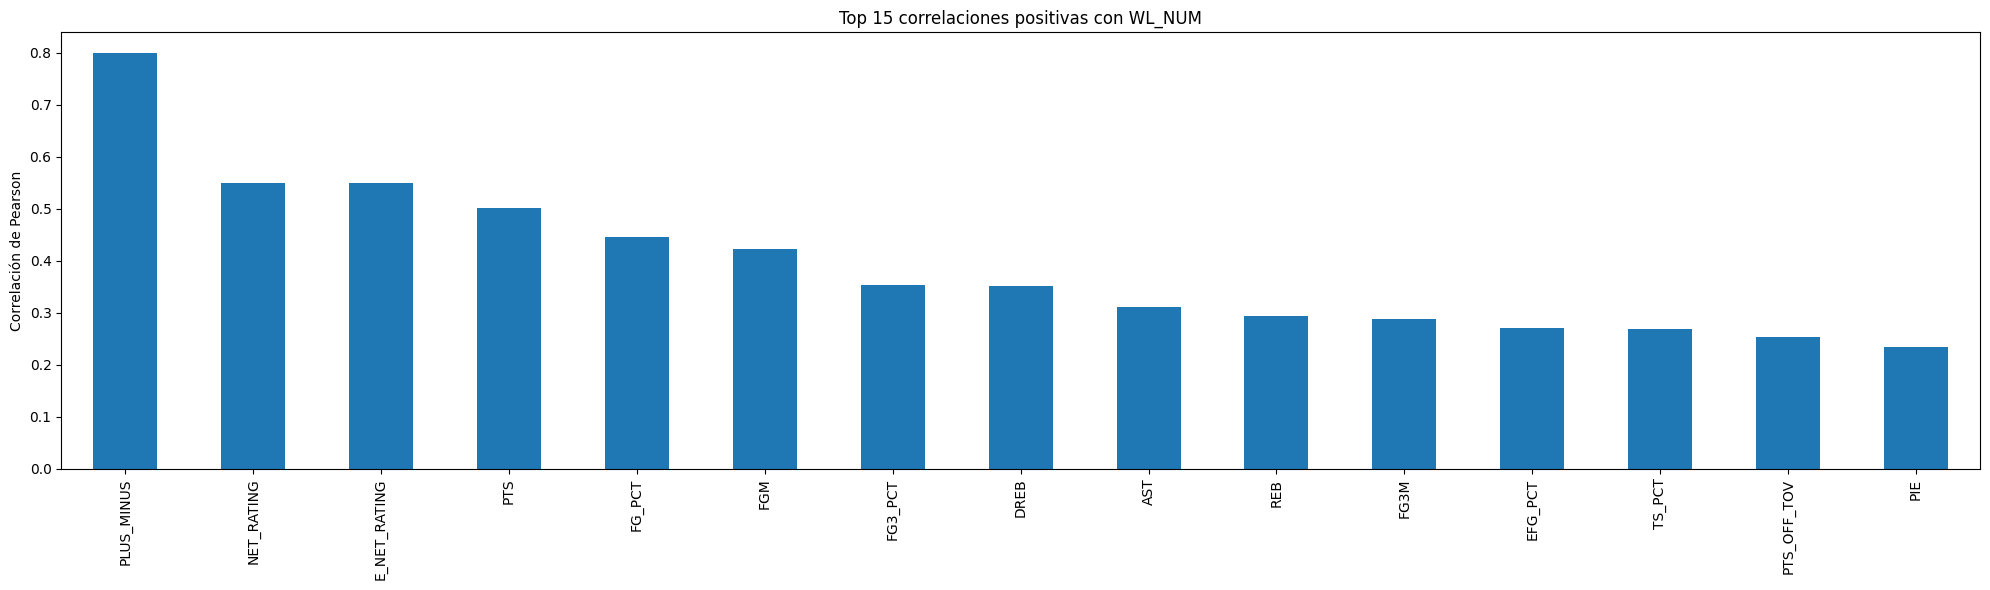

Top 10 correlaciones negativas:


,pearson_correlation
OPP_EFG_PCT,-0.351788
DEF_RATING,-0.270132
E_DEF_RATING,-0.270132
OPP_PTS_OFF_TOV,-0.233276
OPP_PTS_FB,-0.189642
TO,-0.168158
OPP_PTS_PAINT,-0.153808
BLKA,-0.153501
TOV,-0.141119
TM_TOV_PCT,-0.117007


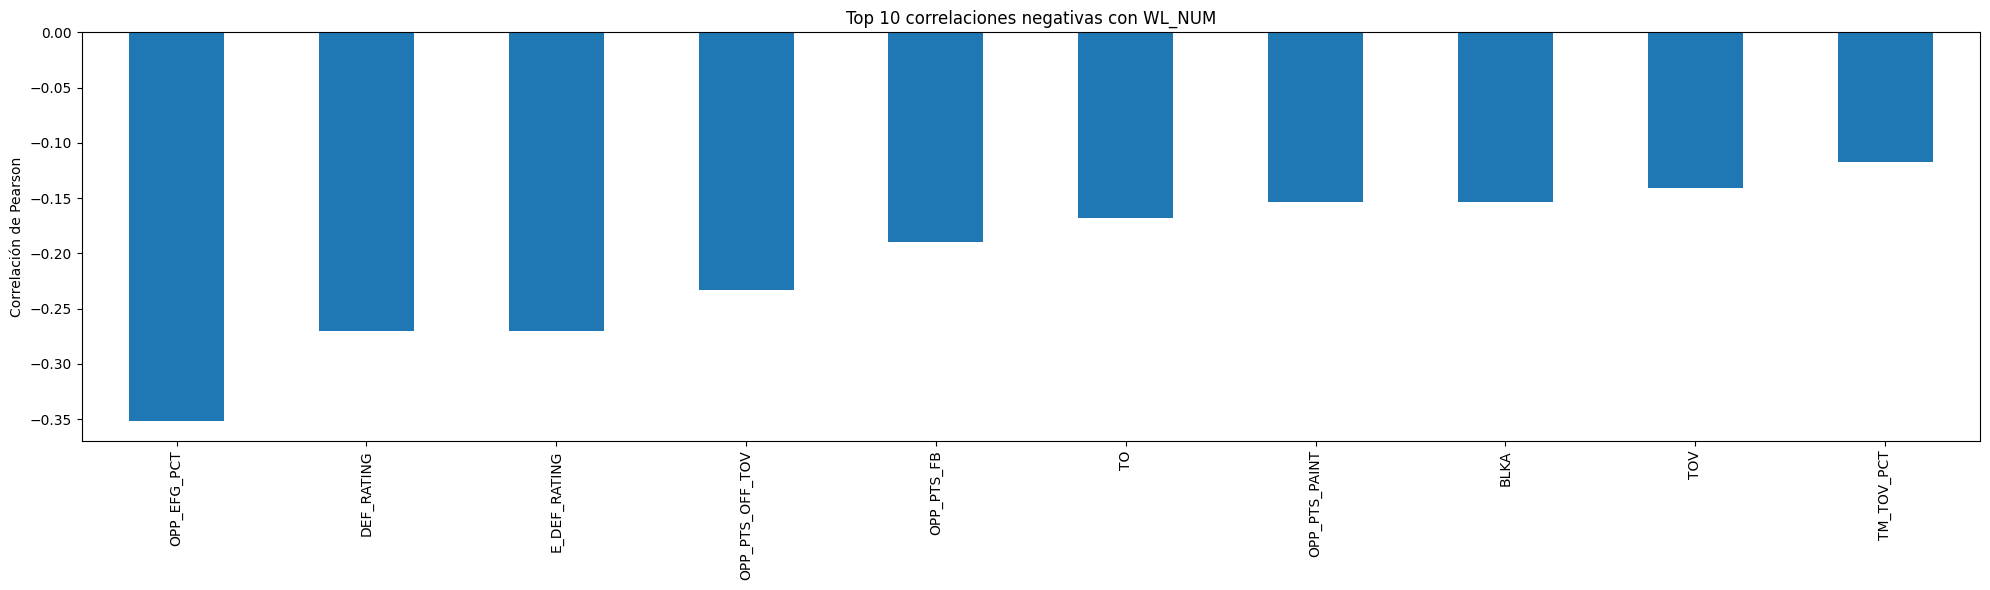

Correlaciones respecto a PLUS_MINUS
Top 15 correlaciones positivas:


,pearson_correlation
NET_RATING,0.770672
E_NET_RATING,0.770672
PTS,0.628160
FGM,0.564630
FG_PCT,0.548589
FG3_PCT,0.436869
AST,0.416957
DREB,0.411669
FG3M,0.381227
OFF_RATING,0.366961


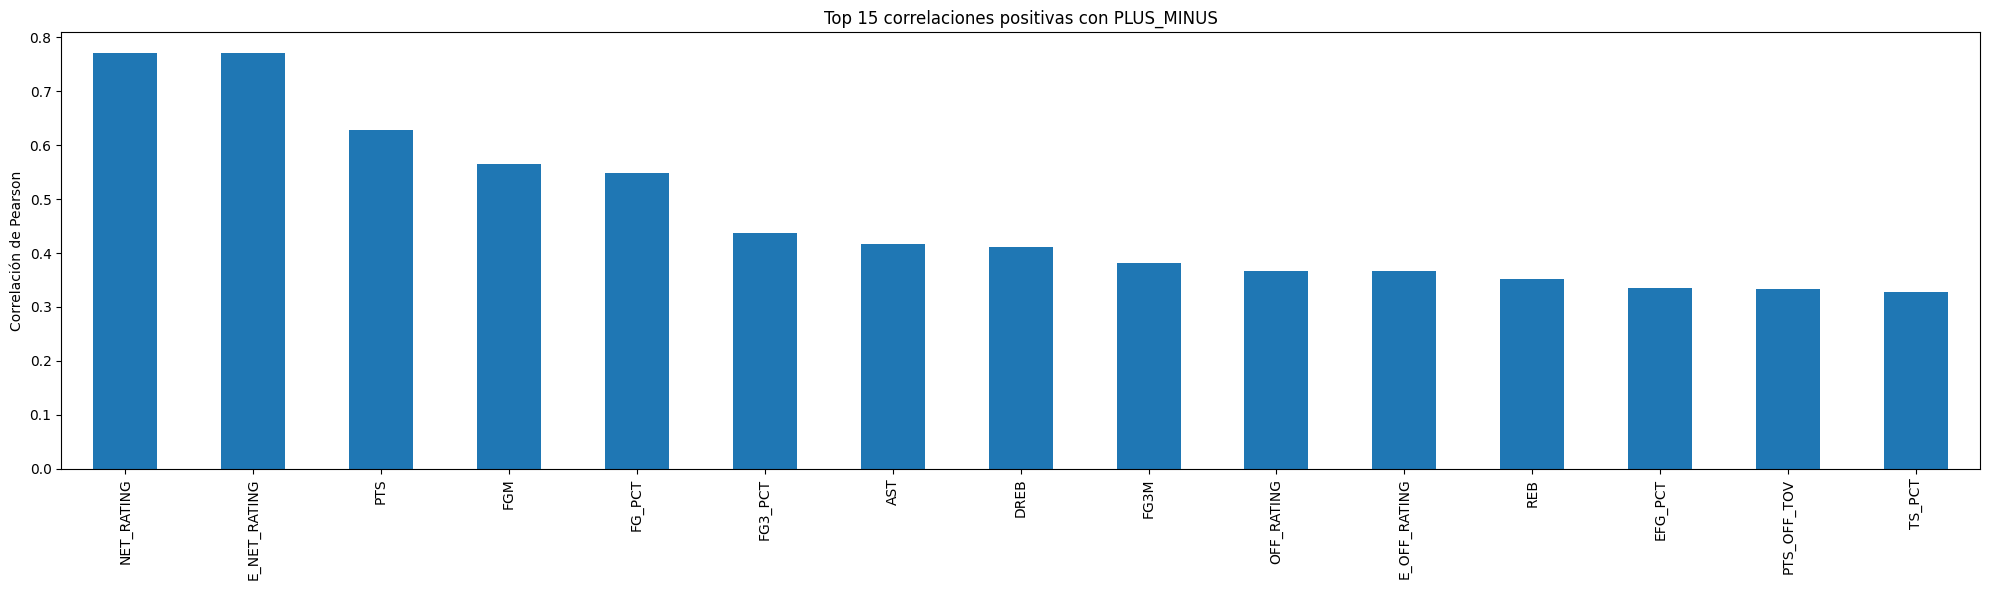

Top 10 correlaciones negativas:


,pearson_correlation
OPP_EFG_PCT,-0.463907
DEF_RATING,-0.331480
E_DEF_RATING,-0.331480
OPP_PTS_OFF_TOV,-0.317157
OPP_PTS_FB,-0.267560
OPP_PTS_PAINT,-0.229736
TO,-0.223015
TOV,-0.196205
TM_TOV_PCT,-0.158161
BLKA,-0.157070


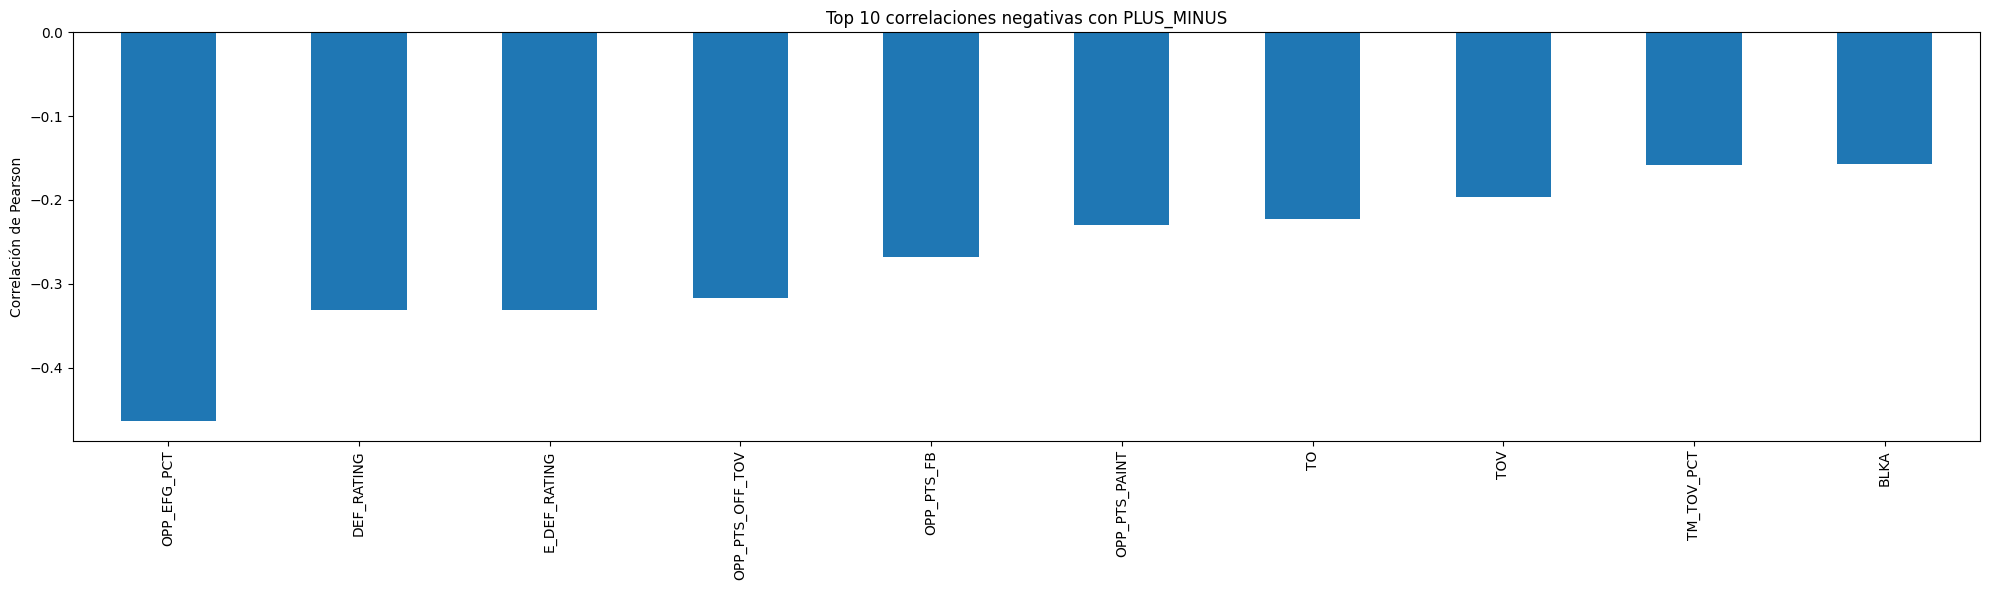

In [6]:
targets = ["WL_NUM", "PLUS_MINUS"]

for target in targets:
    if target not in df.columns:
        print(f"Objetivo '{target}' no encontrado. Se omite el análisis de correlación.")
        continue

    available_features = [feat for feat in valid_features if feat != target]
    if not available_features:
        print(f"No hay features válidas disponibles para correlacionar con {target}.")
        continue

    subset_cols = available_features + [target]
    subset_df = df[subset_cols].dropna()

    if subset_df.empty:
        print(f"Tras aplicar dropna(), no quedan registros completos para el objetivo {target}.")
        continue

    corr_matrix = subset_df.corr(method="pearson")
    corr_series = corr_matrix[target].drop(labels=[target])
    corr_series = corr_series.dropna().sort_values(ascending=False)

    print(f"Correlaciones respecto a {target}")

    positive_corr = corr_series[corr_series > 0].head(15)
    negative_corr = corr_series[corr_series < 0].sort_values().head(10)

    if not positive_corr.empty:
        print("Top 15 correlaciones positivas:")
        display(positive_corr.to_frame(name="pearson_correlation"))

        plt.figure(figsize=(20, 6))
        positive_corr.plot(kind="bar")
        plt.title(f"Top 15 correlaciones positivas con {target}")
        plt.ylabel("Correlación de Pearson")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
    else:
        print("No se encontraron correlaciones positivas.")

    if not negative_corr.empty:
        print("Top 10 correlaciones negativas:")
        display(negative_corr.to_frame(name="pearson_correlation"))

        plt.figure(figsize=(20, 6))
        negative_corr.plot(kind="bar")
        plt.title(f"Top 10 correlaciones negativas con {target}")
        plt.ylabel("Correlación de Pearson")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
    else:
        print("No se encontraron correlaciones negativas.")


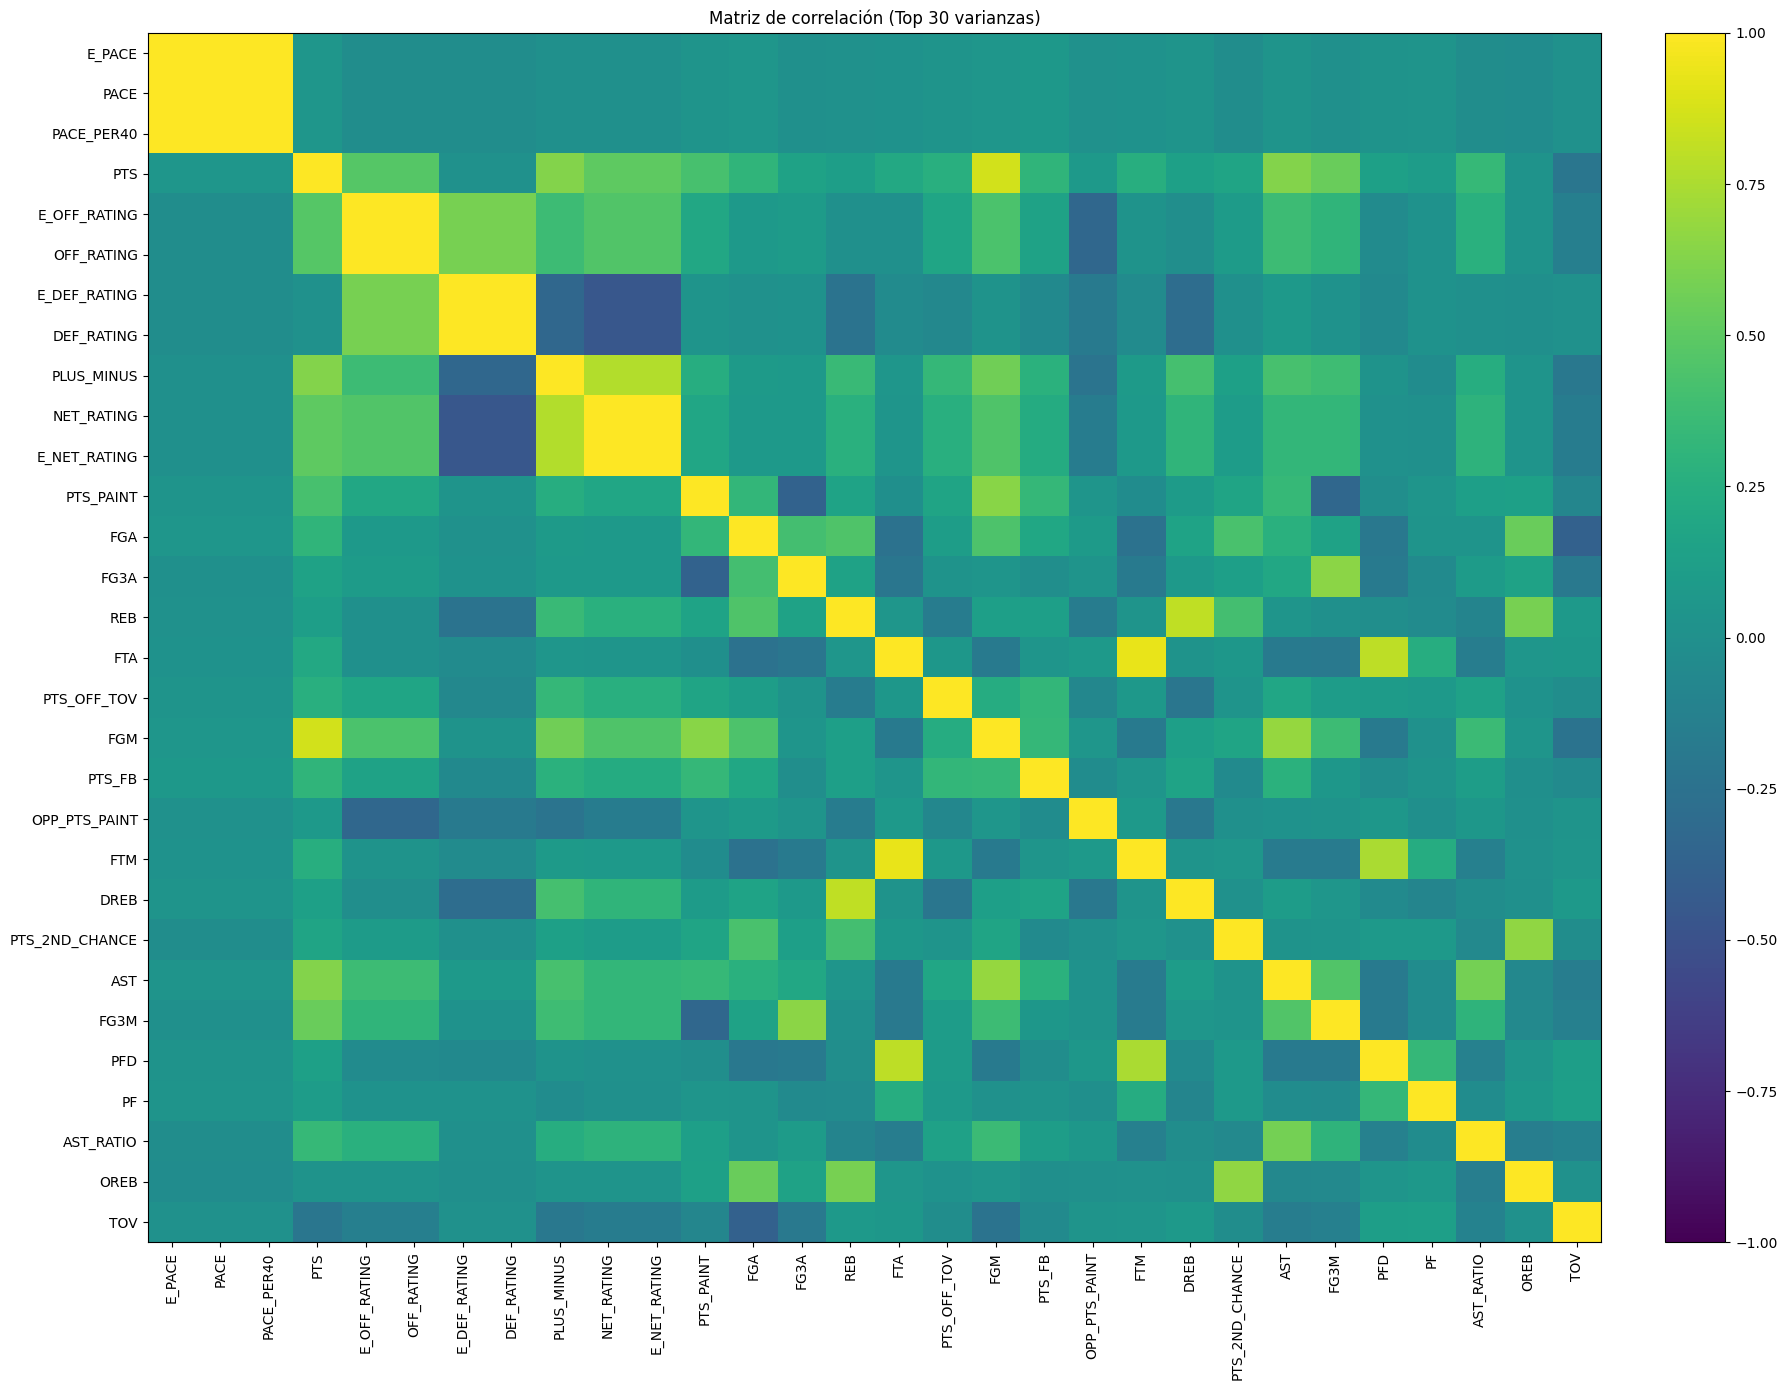

In [7]:
if valid_features:
    variances = df[valid_features].var(numeric_only=True).dropna().sort_values(ascending=False)
    top_var_features = variances.head(30).index.tolist()

    if top_var_features:
        feature_corr_df = df[top_var_features].dropna()
        if not feature_corr_df.empty and len(top_var_features) > 1:
            feature_corr_matrix = feature_corr_df.corr(method="pearson")

            plt.figure(figsize=(18, 14))
            im = plt.imshow(feature_corr_matrix, aspect="auto", vmin=-1, vmax=1)
            plt.colorbar(im, fraction=0.046, pad=0.04)
            plt.xticks(ticks=range(len(top_var_features)), labels=top_var_features, rotation=90)
            plt.yticks(ticks=range(len(top_var_features)), labels=top_var_features)
            plt.title("Matriz de correlación (Top 30 varianzas)")
            plt.tight_layout()
            plt.show()
        else:
            print("No hay suficientes datos completos para calcular la matriz de correlación de features.")
    else:
        print("No hay features con varianza suficiente para el análisis de correlación.")
else:
    print("No hay features válidas para analizar.")


## Nota

Si alguna correlación aparece como `NaN`, se debe a columnas constantes o sin observaciones válidas después del filtrado. Esto se mitiga excluyendo columnas sin variabilidad y aplicando `dropna()` por bloque de análisis.